# 这是新的MLOPS的学习记录
## 我创建了新的学习目录   
/mnt/d/develop/mlops/mlops
## 依然先延用机器学习部分中，quant这个conda创建的虚拟环境，如果python的虚拟环境有相应需求，再创建或者调整quant

# 一、下载数据
- wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2021-01.parquet
- wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2021-02.parquet

# 二、Install a Parquet engine

In [ ]:
# 安装读取parquet格式的依赖
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/mlops# pip install pyarrow
Requirement already satisfied: pyarrow in /root/miniconda3/envs/quant/lib/python3.11/site-packages (24.0.0)

(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/mlops# pip list |grep pyarrow
pyarrow                    24.0.0

# 三、读取数据
- 用pandas加载2021年1月和2月的出租车数据。我们用一月数据作为训练，二月数据作为验证。列中包含接送时间戳、地点ID、行程距离和乘客信息。

In [2]:
import  pandas as pd

In [3]:
df = pd.read_parquet('./data/yellow_tripdata_2021-01.parquet')

In [4]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2021-01-01 00:30:10,2021-01-01 00:36:12,1.0,2.10,1.0,N,142,43,2,8.00,3.00,0.5,0.00,0.00,0.3,11.80,2.5,NaN
1,1,2021-01-01 00:51:20,2021-01-01 00:52:19,1.0,0.20,1.0,N,238,151,2,3.00,0.50,0.5,0.00,0.00,0.3,4.30,0.0,NaN
2,1,2021-01-01 00:43:30,2021-01-01 01:11:06,1.0,14.70,1.0,N,132,165,1,42.00,0.50,0.5,8.65,0.00,0.3,51.95,0.0,NaN
3,1,2021-01-01 00:15:48,2021-01-01 00:31:01,0.0,10.60,1.0,N,138,132,1,29.00,0.50,0.5,6.05,0.00,0.3,36.35,0.0,NaN
4,2,2021-01-01 00:31:49,2021-01-01 00:48:21,1.0,4.94,1.0,N,68,33,1,16.50,0.50,0.5,4.06,0.00,0.3,24.36,2.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369764,2,2021-01-31 23:03:00,2021-01-31 23:33:00,NaN,8.89,NaN,NaN,229,181,0,27.78,0.00,0.5,7.46,0.00,0.3,38.54,NaN,NaN
1369765,2,2021-01-31 23:29:00,2021-01-31 23:51:00,NaN,7.43,NaN,NaN,41,70,0,32.58,0.00,0.5,0.00,6.12,0.3,39.50,NaN,NaN
1369766,2,2021-01-31 23:25:00,2021-01-31 23:38:00,NaN,6.26,NaN,NaN,74,137,0,16.85,0.00,0.5,3.90,0.00,0.3,24.05,NaN,NaN
1369767,6,2021-01-31 23:01:06,2021-02-01 00:02:03,NaN,19.70,NaN,NaN,265,188,0,53.68,0.00,0.5,0.00,0.00,0.3,54.48,NaN,NaN


In [5]:
df2 = pd.read_parquet('./data/yellow_tripdata_2021-02.parquet')

In [6]:
df2

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2021-02-01 00:40:47,2021-02-01 00:48:28,1.0,2.30,1.0,N,141,226,2,8.50,3.00,0.5,0.00,0.0,0.3,12.30,2.5,NaN
1,1,2021-02-01 00:07:44,2021-02-01 00:20:31,1.0,1.60,1.0,N,43,263,2,9.50,3.00,0.5,0.00,0.0,0.3,13.30,0.0,NaN
2,1,2021-02-01 00:59:36,2021-02-01 01:24:13,1.0,5.30,1.0,N,114,263,2,19.00,3.00,0.5,0.00,0.0,0.3,22.80,2.5,NaN
3,2,2021-02-01 00:03:26,2021-02-01 00:16:32,1.0,2.79,1.0,N,236,229,1,11.00,0.50,0.5,2.96,0.0,0.3,17.76,2.5,NaN
4,2,2021-02-01 00:20:20,2021-02-01 00:24:03,2.0,0.64,1.0,N,229,140,1,4.50,0.50,0.5,1.66,0.0,0.3,9.96,2.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1371704,6,2021-02-28 23:02:08,2021-02-28 23:02:02,NaN,16.09,NaN,NaN,265,3,0,42.55,0.00,0.5,0.00,0.0,0.3,43.35,NaN,NaN
1371705,2,2021-02-28 23:27:00,2021-02-28 23:41:00,NaN,4.42,NaN,NaN,68,24,0,17.14,0.00,0.5,4.33,0.0,0.3,24.77,NaN,NaN
1371706,2,2021-02-28 23:18:05,2021-02-28 23:26:48,NaN,1.50,NaN,NaN,68,137,0,9.46,0.00,0.5,2.64,0.0,0.3,15.40,NaN,NaN
1371707,2,2021-02-28 23:41:07,2021-03-01 00:13:44,NaN,15.30,NaN,NaN,113,254,0,59.15,2.75,0.5,0.00,0.0,0.3,62.70,NaN,NaN


In [7]:
# 通过用接送时间减去目标时间。将结果转换为分钟，然后保持合理的持续时间范围，避免极端记录占据模型主导。
df['duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [8]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
duration                        float64
dtype: object

In [9]:
df2['duration'] = (
    df2['tpep_dropoff_datetime'] - df2['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [10]:
df2.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
duration                        float64
dtype: object

In [11]:
df = df[(df.duration >= 1) & (df.duration <= 60)]

In [12]:
len(df)

1343254

In [13]:
df2 = df2[(df2.duration >= 1) & (df2.duration <= 60)]

In [14]:
len(df2)

1340859

# 四、构建特征矩阵


In [15]:
print(df[['PULocationID', 'DOLocationID','trip_distance']].dtypes)

PULocationID       int64
DOLocationID       int64
trip_distance    float64
dtype: object


In [16]:
# 把上下车时间，作为分类特征
categorical = ['PULocationID', 'DOLocationID']
# 把目的地，作为数值特征
numerical = ['trip_distance']

In [17]:
# 将分类特征中的内容，全部转换为字符串类型
df[categorical] = df[categorical].astype(str)
df2[categorical] = df2[categorical].astype(str)

In [18]:
print(df[['PULocationID', 'DOLocationID']].dtypes)

PULocationID    str
DOLocationID    str
dtype: object


In [19]:
# 将含有分类特征和数值特征的训练数据，转换为列表字典
train_dicts = df[categorical + numerical].to_dict(orient='records')

In [20]:
from sklearn.feature_extraction import DictVectorizer

In [21]:
# 没有sparse=False 参数 ，采用稀疏矩阵，大量数据做了独热处理后，可能展开了巨多的列，列里面有非常多的0，需要采用稀疏矩阵来处理
dv = DictVectorizer()

In [22]:
X_train = dv.fit_transform(train_dicts)

In [23]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4029762 stored elements and shape (1343254, 519)>

In [24]:
y_train = df['duration'].values

In [25]:
val_dicts = df2[categorical + numerical].to_dict(orient='records')

In [26]:
X_val = dv.transform(val_dicts)

In [27]:
y_val = df2['duration'].values

# 五、训练模型 

In [28]:
# 训练线性回归模型，，并以均方根误差测量其误差
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)


In [30]:
y_pred

array([15.28866976,  9.54554317,  9.16714001, ..., 10.040403  ,
       22.57658932, 13.50451214], shape=(1340859,))

In [31]:
rmse = root_mean_squared_error(y_val, y_pred)

In [32]:
rmse

7.428631092847934

### 模型预测的行程时长，平均误差约 7.43 分钟。

In [33]:
y_val.mean()

np.float64(12.368008878388158)

In [34]:
y_pred.mean()

np.float64(11.471435868879441)

In [35]:
y_val.min()

np.float64(1.0)

In [36]:
y_val.max()

np.float64(60.0)

In [38]:
import  numpy  as np
np.median(y_val)

np.float64(9.816666666666666)

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

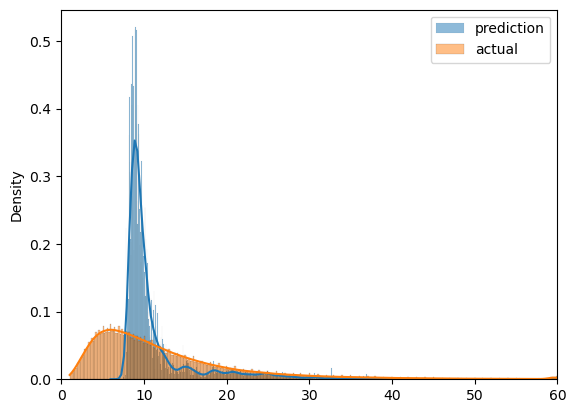

In [40]:
sns.histplot(y_pred, label='prediction', kde=True, stat='density', alpha=0.5)
sns.histplot(y_val, label='actual', kde=True, stat='density', alpha=0.5)
plt.xlim(0, 60)
plt.legend()
plt.show()
# 数值作为x轴，y轴表示对应数值出现的密度，plt.xlim(0, 60)表示0-60分钟

In [46]:
import pickle

# 保存模型
with open('01_duration_model.bin', 'wb') as f_out:
    pickle.dump((dv, model), f_out)

## 将上面的过程写成1个函数

In [41]:
# 将上面的过程写成1个函数
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    numerical = ['trip_distance']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [42]:
df_train = read_dataframe('./data/yellow_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/yellow_tripdata_2021-02.parquet')

In [43]:
len(df_train), len(df_val)

(1343254, 1340859)

In [44]:
df_train.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                        str
DOLocationID                        str
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
duration                        float64
dtype: object

In [45]:
df_val.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                        str
DOLocationID                        str
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
duration                        float64
dtype: object

In [ ]:
# 接下来，就可以翻回头去，到CELL 16
只需要把 df 替换为  df_train   df2  替换为 df_val 
不再演示了，避免繁冗的描述，主要是告诉大家，将步骤写成函数的方式

##  使用带有正则化功能的线性回归

In [47]:
# 
from sklearn.linear_model import Lasso

lr = Lasso(0.01)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
print(rmse)


7.785760681000581


###  结果大于没有正则化处理的模型rmse值0.36个，误差增加，放弃正则化处理。

In [49]:
from sklearn.linear_model import Ridge

for alpha in [0.01, 0.1, 1.0]:
    lr = Ridge(alpha=alpha)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    print(f"alpha={alpha}, RMSE={rmse}")

alpha=0.01, RMSE=7.424193058717717
alpha=0.1, RMSE=7.424189672025798
alpha=1.0, RMSE=7.424145300384685


### 要么特征之间共线性不严重；
### 要么这个数据量足够大（134 万训练样本），正则化的影响被稀释了。

## 所以，对这个数据来说，加不加 Ridge、alpha 取多少，差别可以忽略。普通线性回归就够了。